# Preprocessing

In [142]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [143]:
df=pd.read_csv(r"C:\Users\mnour\Downloads\Problem_2\Problem_2\Mart_Sales.csv")

In [144]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [145]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [146]:
df.shape

(8523, 12)

In [147]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


# Handling missing values

Before doing anything, find out where the "missing" in the data are

In [148]:
# check missing values
pd.DataFrame(df.isnull().sum(),columns=['Missing Values Count'])

,Missing Values Count
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


okay now we found number of missing values

- <b> features to be removed ---> 80%  is nan
- <b> features to filled --------> less than 80 %
- <b> observation to be removed --> less than 3%

In [149]:
# percentage of the missing values
pd.DataFrame(df.isnull().sum()/len(df)*100,columns=['Missing Values Percentage'])


,Missing Values Percentage
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [150]:
# Okay both of the missing 2 columns are numerical column, Categorial so what do you think we will fill the 2 Null values columns with????
# # if null count is > 3% and < 80%  fill it by mean
# Use double brackets to pass a list of column names
cols_to_fix = ["Item_Weight", "Outlet_Size"]
df[cols_to_fix] = df[cols_to_fix].fillna(df[cols_to_fix].mode().iloc[0])



In [151]:
# lets check if the missing values are filled or not
pd.DataFrame(df.isnull().sum(),columns=['Missing Values Count'])


,Missing Values Count
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [152]:
# Okay now lets check if there is duplicates in the data


# Handling outliers

know we will check for the outliers and we will trys 2 ways.

how the boxplot visualize
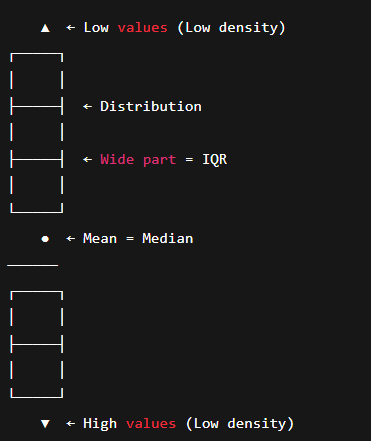

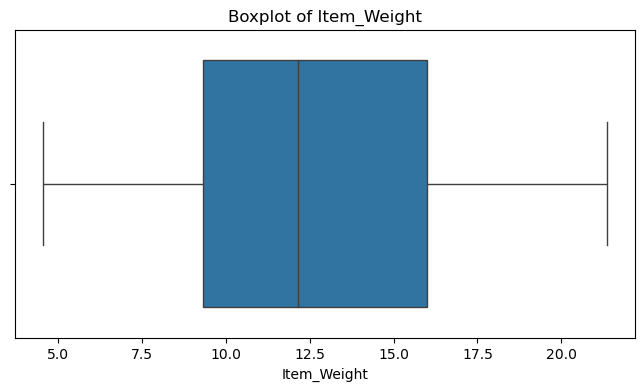

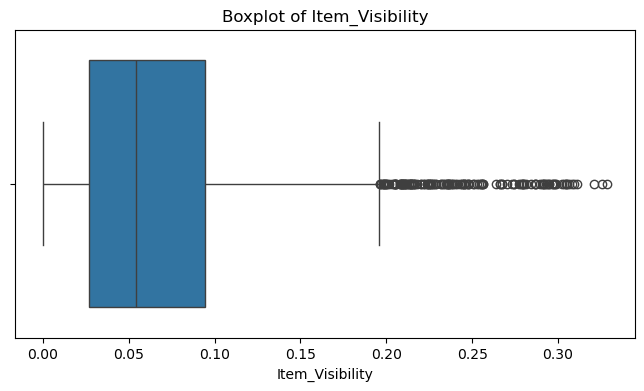

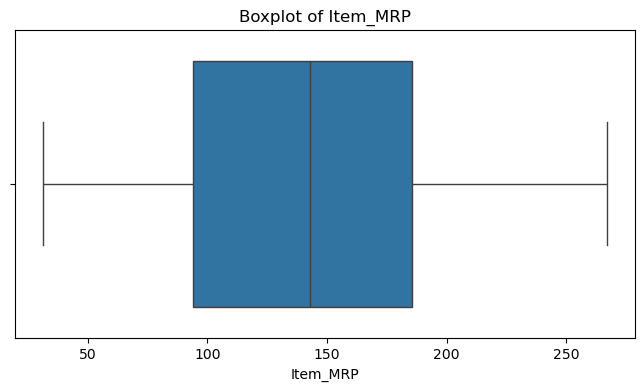

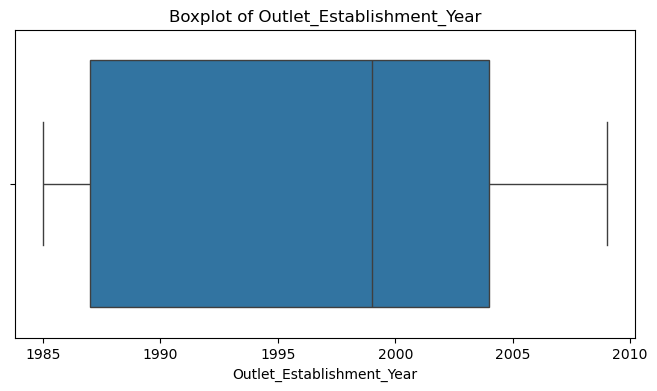

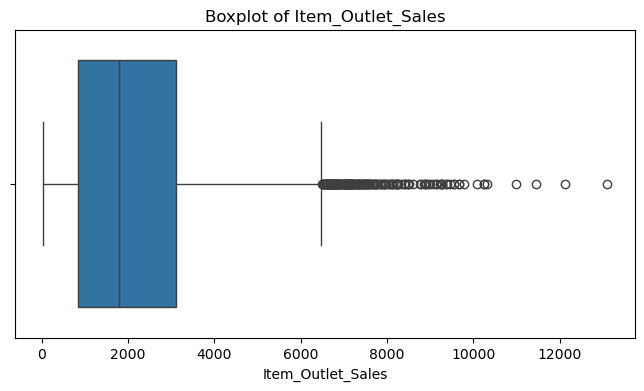

In [153]:
#Boxplot Method (Visualization)
# don't forget to make sure that while using boxplot or checking the outliers you can't pass any categorical columns

numerical_columns = ['Item_Weight','Item_Visibility','Item_MRP',
                    'Outlet_Establishment_Year','Item_Outlet_Sales']
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()  



In [154]:
#IQR Method
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numerical_columns] < (Q1 - 1.5 * IQR)) | (df[numerical_columns] > (Q3 + 1.5 * IQR))).sum()
print(outliers)



Item_Weight                    0
Item_Visibility              144
Item_MRP                       0
Outlet_Establishment_Year      0
Item_Outlet_Sales            186
dtype: int64


now you will see 2 columns with outliers and we will try to handle oultiers in those 2 columns

In [155]:
def handle_outliers_iqr(df, method="cap", target_col=None):

    df = df.copy()
    cleaned_cols = []

    num_cols = df.select_dtypes(include='number').columns

    for col in num_cols:

 
        if col == target_col:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if method == "cap":
            df[col] = df[col].clip(lower, upper)

  
        elif method == "drop":
            df = df[(df[col] >= lower) & (df[col] <= upper)]

        cleaned_cols.append(col)


    return df
df_clean = handle_outliers_iqr(df, method="drop")
df_clean.describe().T



,count,mean,std,min,25%,50%,75%,max
Item_Weight,8193.0,12.753117,4.274890,4.555,9.300000,12.150000,16.100000,21.350000
Item_Visibility,8193.0,0.063221,0.046285,0.000,0.026818,0.052729,0.092783,0.195721
Item_MRP,8193.0,139.104030,61.536438,31.290,92.980400,141.147000,183.663400,266.888400
Outlet_Establishment_Year,8193.0,1998.089711,8.286946,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8193.0,2089.540121,1501.498356,33.290,857.550400,1783.678200,3020.068800,6478.234000


# Skewness Handling


In [156]:

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
skewness = df_clean[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric features:")
print(skewness)


Skewness of numeric features:
Item_Outlet_Sales            0.768515
Item_Visibility              0.735164
Item_Weight                  0.164466
Item_MRP                     0.151462
Outlet_Establishment_Year   -0.438117
dtype: float64


In [157]:
# Apply log transformation for features with |skewness| > 1
for col in numeric_cols:
    if abs(skewness[col]) > 1:
        df_clean[col] = np.log1p(df_clean[col]) 

# Encoding Categorical columns

In [158]:
#Encode categorical features with label encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
label_encoder = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_clean[col] = label_encoder.fit_transform(df_clean[col])
for i in df_clean.columns:
    df_clean[i] = MinMaxScaler().fit_transform(df_clean[[i]])
df_clean.head()



,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,0.100128,0.282525,0.25,0.081991,0.266667,0.927507,1.000000,0.583333,0.5,0.0,0.333333,0.574380
1,0.005135,0.081274,0.50,0.098498,0.933333,0.072068,0.333333,1.000000,0.5,1.0,0.666667,0.063636
2,0.424904,0.770765,0.25,0.085632,0.666667,0.468288,1.000000,0.583333,0.5,0.0,0.333333,0.320248
3,0.719512,0.871986,0.50,0.000000,0.400000,0.640093,0.000000,0.541667,0.5,1.0,0.000000,0.108471
4,0.832478,0.260494,0.25,0.000000,0.600000,0.095805,0.111111,0.083333,0.0,1.0,0.333333,0.149174


In [159]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8193 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8193 non-null   float64
 1   Item_Weight                8193 non-null   float64
 2   Item_Fat_Content           8193 non-null   float64
 3   Item_Visibility            8193 non-null   float64
 4   Item_Type                  8193 non-null   float64
 5   Item_MRP                   8193 non-null   float64
 6   Outlet_Identifier          8193 non-null   float64
 7   Outlet_Establishment_Year  8193 non-null   float64
 8   Outlet_Size                8193 non-null   float64
 9   Outlet_Location_Type       8193 non-null   float64
 10  Outlet_Type                8193 non-null   float64
 11  Item_Outlet_Sales          8193 non-null   float64
dtypes: float64(12)
memory usage: 832.1 KB
